In [ ]:
#some bug fixes required in this. Uses website incorrect forms/invoices.

In [ ]:
from transformers import AutoProcessor

# we'll use the Auto API here - it will load LayoutLMv3Processor behind the scenes,
# based on the checkpoint we provide from the hub
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

In [ ]:
import numpy as np
from datasets.features import ClassLabel
from PIL import Image # Import PIL
from datasets import load_dataset
from transformers import AutoProcessor

# we'll use the Auto API here - it will load LayoutLMv3Processor behind the scenes,
# based on the checkpoint we provide from the hub
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

dataset = load_dataset("nielsr/funsd")

return_entity_level_metrics = False

features = dataset["train"].features
column_names = dataset["train"].column_names
image_column_name = "image"
text_column_name = "words"
boxes_column_name = "bboxes"
label_column_name = "ner_tags"

# In the event the labels are not a `Sequence[ClassLabel]`, we will need to go through the dataset to get the
# unique labels.
def get_label_list(labels):
    unique_labels = set()
    for label in labels:
        unique_labels = unique_labels | set(label)
    label_list = list(unique_labels)
    label_list.sort()
    return label_list


def unnormalize_box(bbox, width, height):
     return [
         width * (bbox[0] / 1000),
         height * (bbox[1] / 1000),
         width * (bbox[2] / 1000),
         height * (bbox[3] / 1000),
     ]


# Tokenize the inputs
def prepare_examples(examples):
    images = examples[image_column_name]
    words = examples[text_column_name]
    boxes = examples[boxes_column_name]
    word_labels = examples[label_column_name]

    # Convert images to grayscale and then to numpy array, ensure 3 dimensions
    processed_images = []
    for img in images:
        img = img.convert("L") # Convert to grayscale
        img_np = np.array(img) # Convert PIL Image to NumPy array
        if img_np.ndim == 2:
            img_np = np.expand_dims(img_np, axis=-1) # Add a channel dimension
        # Ensure image has 3 dimensions, repeating the single channel 3 times
        if img_np.shape[-1] == 1:
            img_np = np.repeat(img_np, 3, axis=-1)
        processed_images.append(img_np)


    encoding = processor(processed_images, words, boxes=boxes, word_labels=word_labels,
                       truncation=True, padding="max_length")

    return encoding


def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    if return_entity_level_metrics:
        # Unpack nested dictionaries
        final_results = {}
        for key, value in results.items():
            if isinstance(value, dict):
                for n, v in value.items():
                    final_results[f"{key}_{n}"] = v
            else:
                final_results[key] = value
        return final_results
    else:
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
            "accuracy": results["overall_accuracy"],
        }


if isinstance(features[label_column_name].feature, ClassLabel):
    label_list = features[label_column_name].feature.names
    # No need to convert the labels since they are already ints.
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
else:
    label_list = get_label_list(dataset["train"][label_column_name])
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
num_labels = len(label_list)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from datasets import load_dataset

dataset = load_dataset("nielsr/funsd")

In [ ]:
from datasets import Features, Sequence, ClassLabel, Value, Array2D, Array3D

# we need to define custom features for `set_format` (used later on) to work properly
features = Features({
    'pixel_values': Array3D(dtype="float32", shape=(3, 224, 224)),
    'input_ids': Sequence(feature=Value(dtype='int64')),
    'attention_mask': Sequence(Value(dtype='int64')),
    'bbox': Array2D(dtype="int64", shape=(512, 4)),
    'labels': Sequence(feature=Value(dtype='int64')),
})

train_dataset = dataset["train"].map(
    prepare_examples,
    batched=True,
    remove_columns=column_names,
    features=features,
)
eval_dataset = dataset["test"].map(
    prepare_examples,
    batched=True,
    remove_columns=column_names,
    features=features,
)

Map:   0%|          | 0/149 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [ ]:
print(dataset["train"].column_names)

['id', 'words', 'bboxes', 'ner_tags', 'image']


In [ ]:
import evaluate

metric = evaluate.load("seqeval")

In [ ]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=a21d33677786bade434ab9413bcb89789eb59c47b0e2b57ca0771f7c36e59d2e
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
from transformers import LayoutLMv3ForTokenClassification

model = LayoutLMv3ForTokenClassification.from_pretrained("microsoft/layoutlmv3-base",
                                                         id2label=id2label,
                                                         label2id=label2id)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of LayoutLMv3ForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlmv3-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="test",
    num_train_epochs=2,  # ⬅️ run for 2 passes over dataset
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=1e-5,
    load_best_model_at_end=False,
    metric_for_best_model="f1",
    report_to="none",
)

In [ ]:
!pip install -U transformer

ERROR: Could not find a version that satisfies the requirement transformer (from versions: none)
ERROR: No matching distribution found for transformer


In [ ]:
from transformers.data.data_collator import default_data_collator

# Initialize our Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-3954989940.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1742: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


Step,Training Loss


TrainOutput(global_step=150, training_loss=1.240440673828125, metrics={'train_runtime': 2473.0334, 'train_samples_per_second': 0.12, 'train_steps_per_second': 0.061, 'total_flos': 78554392283136.0, 'train_loss': 1.240440673828125, 'epoch': 2.0})

In [ ]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1742: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


{'eval_loss': 0.869343638420105,
 'eval_precision': 0.5276338514680483,
 'eval_recall': 0.6070541480377546,
 'eval_f1': 0.5645645645645645,
 'eval_accuracy': 0.7052181148222988,
 'eval_runtime': 106.511,
 'eval_samples_per_second': 0.469,
 'eval_steps_per_second': 0.235,
 'epoch': 2.0}

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained("/content/test/checkpoint-150")

In [ ]:
import numpy as np
from PIL import Image

example = dataset["test"][0]
image = example["image"]
words = example["words"]
boxes = example["bboxes"]
word_labels = example["ner_tags"]

# Convert images to grayscale and then to numpy array, ensure 3 dimensions
image = image.convert("L") # Convert to grayscale
img_np = np.array(image) # Convert PIL Image to NumPy array
if img_np.ndim == 2:
    img_np = np.expand_dims(img_np, axis=-1) # Add a channel dimension
# Ensure image has 3 dimensions, repeating the single channel 3 times
if img_np.shape[-1] == 1:
    img_np = np.repeat(img_np, 3, axis=-1)
processed_image = Image.fromarray(img_np)


encoding = processor(processed_image, words, boxes=boxes, word_labels=word_labels, return_tensors="pt")
for k,v in encoding.items():
  print(k,v.shape)

input_ids torch.Size([1, 360])
attention_mask torch.Size([1, 360])
bbox torch.Size([1, 360, 4])
labels torch.Size([1, 360])
pixel_values torch.Size([1, 3, 224, 224])


In [ ]:
import torch
import numpy as np
from PIL import Image

def unnormalize_box(bbox, width, height):
     return [
         width * (bbox[0] / 1000),
         height * (bbox[1] / 1000),
         width * (bbox[2] / 1000),
         height * (bbox[3] / 1000),
     ]

example = dataset["test"][0]
image = example["image"]
words = example["words"]
boxes = example["bboxes"]
word_labels = example["ner_tags"]

# Convert images to grayscale and then to numpy array, ensure 3 dimensions
image = image.convert("L") # Convert to grayscale
img_np = np.array(image) # Convert PIL Image to NumPy array
if img_np.ndim == 2:
    img_np = np.expand_dims(img_np, axis=-1) # Add a channel dimension
# Ensure image has 3 dimensions, repeating the single channel 3 times
if img_np.shape[-1] == 1:
    img_np = np.repeat(img_np, 3, axis=-1)
processed_image = Image.fromarray(img_np)


encoding = processor(processed_image, words, boxes=boxes, word_labels=word_labels, return_tensors="pt")

with torch.no_grad():
    outputs = model(**encoding)

logits = outputs.logits
predictions = logits.argmax(-1).squeeze().tolist()
labels = encoding.labels.squeeze().tolist()

token_boxes = encoding.bbox.squeeze().tolist()
width, height = image.size

true_predictions = [model.config.id2label[pred] for pred, label in zip(predictions, labels) if label != - 100]
true_labels = [model.config.id2label[label] for prediction, label in zip(predictions, labels) if label != -100]
true_boxes = [unnormalize_box(box, width, height) for box, label in zip(token_boxes, labels) if label != -100]

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1742: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


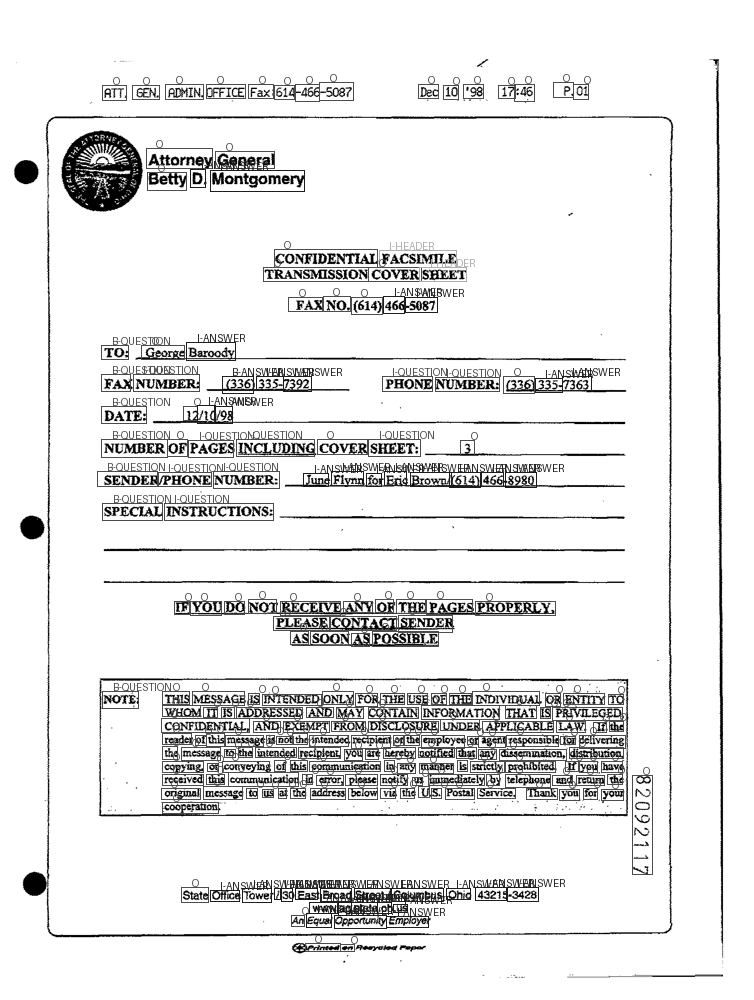

In [ ]:
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(image)

font = ImageFont.load_default()

def iob_to_label(label):
    # The true_predictions already contain the relevant labels, so we can return them directly
    return label

# Update label2color to include all possible labels with a default color
label2color = {label: 'red' for label in id2label.values()}

# Assign specific colors to the labels we want to highlight
label2color['B-ANSWER'] = 'blue'
label2color['I-ANSWER'] = 'blue'
label2color['B-QUESTION'] = 'green'
label2color['I-QUESTION'] = 'green'
label2color['B-HEADER'] = 'orange'
label2color['I-HEADER'] = 'orange'
label2color['O'] = 'red'


for prediction, box in zip(true_predictions, true_boxes):
    predicted_label = iob_to_label(prediction) # Use the simplified function
    # Check if the predicted_label exists in the updated label2color dictionary
    if predicted_label in label2color:
        draw.rectangle(box, outline=label2color[predicted_label])
        draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill=label2color[predicted_label], font=font)
    else:
        # Handle cases where a predicted label is not in label2color (e.g., if new labels are introduced)
        # For now, we can draw with a default color or skip
        print(f"Warning: No color defined for label: {predicted_label}")
        draw.rectangle(box, outline='gray') # Draw with gray for unknown labels
        draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill='gray', font=font)


image